In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import pickle


In [2]:
#Load the dataset
df= pd.read_csv("student_dropout_dataset_v3.csv")

check the structure and dtypes

In [3]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [4]:
df.tail()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0
9999,10000,22.4,Female,76796.0,Yes,4.95,83.7,1,15.5,Yes,No,7.9,2.17,2.20,2.20,Year 1,Arts,Master,0


In [5]:
df.dtypes

Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

In [7]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [8]:
df.shape

(10000, 19)

In [9]:
# Check for missing values
df.isnull().sum()

Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [10]:
df['Family_Income'].median()

np.float64(29740.5)

In [11]:
df['Study_Hours_per_Day'].median()

np.float64(4.0)

In [12]:
df['Stress_Index'].median()

np.float64(5.5)

In [13]:
df['Parental_Education'].mode()

0    Bachelor
Name: Parental_Education, dtype: object

fill missing values with median and mode

In [14]:
df['Family_Income']=df['Family_Income'].fillna(df['Family_Income'].median())

In [15]:
df['Study_Hours_per_Day']=df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].median())

In [17]:
df['Stress_Index']=df['Stress_Index'].fillna(df['Stress_Index'].median())

In [18]:
df['Parental_Education']=df['Parental_Education'].fillna(df['Parental_Education'].mode()[0])

In [19]:
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.select_dtypes(include='number').columns

Index(['Student_ID', 'Age', 'Family_Income', 'Study_Hours_per_Day',
       'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes',
       'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Dropout'],
      dtype='object')

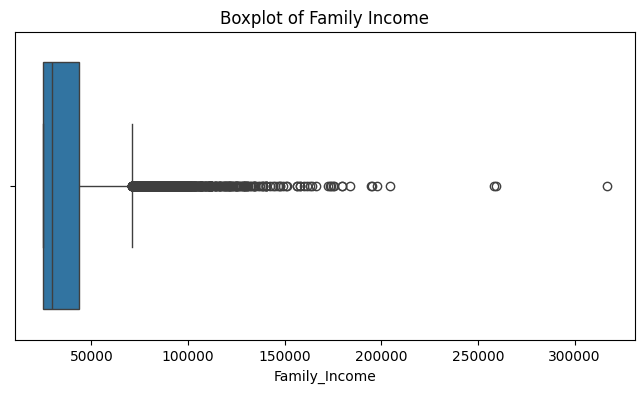

In [22]:
# Visualize the distribution of Family Income and identify potential outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Family_Income'])
plt.title("Boxplot of Family Income")
plt.show()

In [23]:
Q1 = df['Family_Income'].quantile(0.25)
Q3 = df['Family_Income'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df[
    (df['Family_Income'] < lower_bound) |
    (df['Family_Income'] > upper_bound)
]
print("Number of outliers:", len(outliers))

Number of outliers: 683


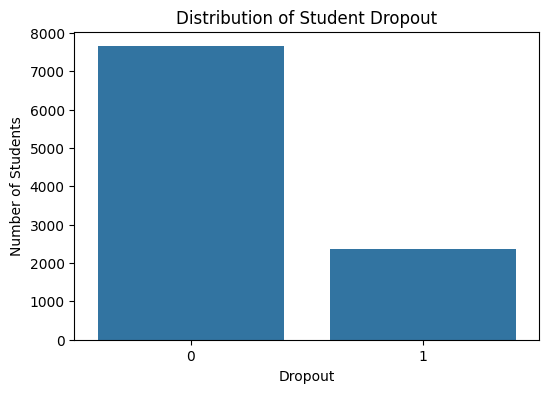

In [24]:
# Visualize the distribution of student dropout status
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Dropout')
plt.title('Distribution of Student Dropout')
plt.xlabel('Dropout')
plt.ylabel('Number of Students')
plt.show()

In [25]:
df['Dropout'].value_counts()

Dropout
0    7646
1    2354
Name: count, dtype: int64

In [26]:
df['Dropout'].value_counts(normalize=True)*100

Dropout
0    76.46
1    23.54
Name: proportion, dtype: float64

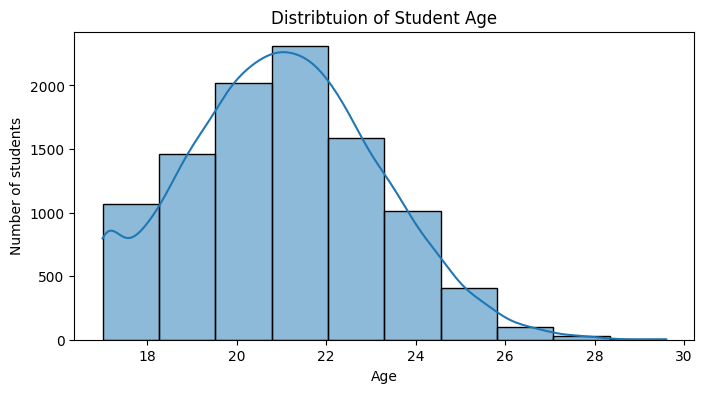

In [27]:
# Visualize the distribution of student ages
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='Age', bins=10, kde=True)
plt.title('Distribtuion of Student Age')
plt.xlabel('Age')
plt.ylabel('Number of students')
plt.show()

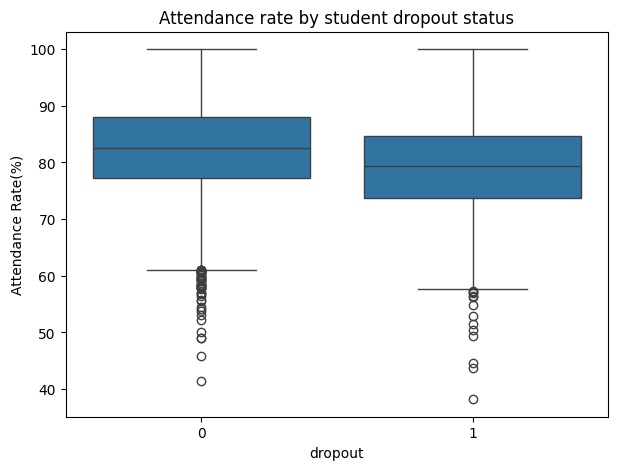

In [28]:
# Compare attendance rates between dropout and non-dropout students
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Dropout', y='Attendance_Rate')
plt.title('Attendance rate by student dropout status')
plt.xlabel('dropout')
plt.ylabel('Attendance Rate(%)')
plt.show()

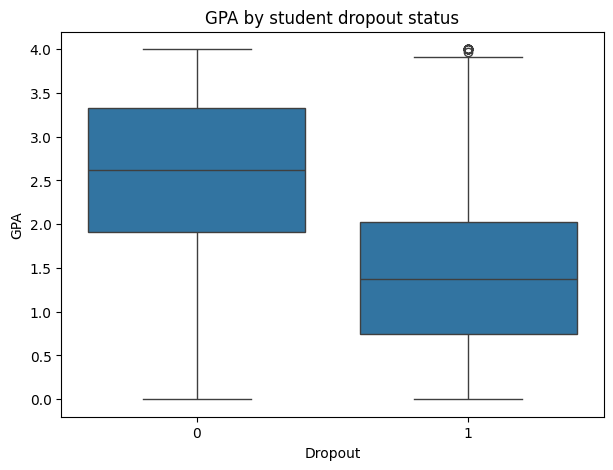

In [29]:
# Compare GPA between dropout and non-dropout students
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Dropout', y='GPA')
plt.title('GPA by student dropout status')
plt.xlabel('Dropout')
plt.ylabel('GPA')
plt.show()

In [30]:
department_dropout=(
    df.groupby('Department')['Dropout']
    .mean()
    .sort_values(ascending=False)*100

)
print(department_dropout)

Department
Engineering    24.006195
Arts           23.938796
CS             23.404255
Business       23.326673
Science        23.047065
Name: Dropout, dtype: float64


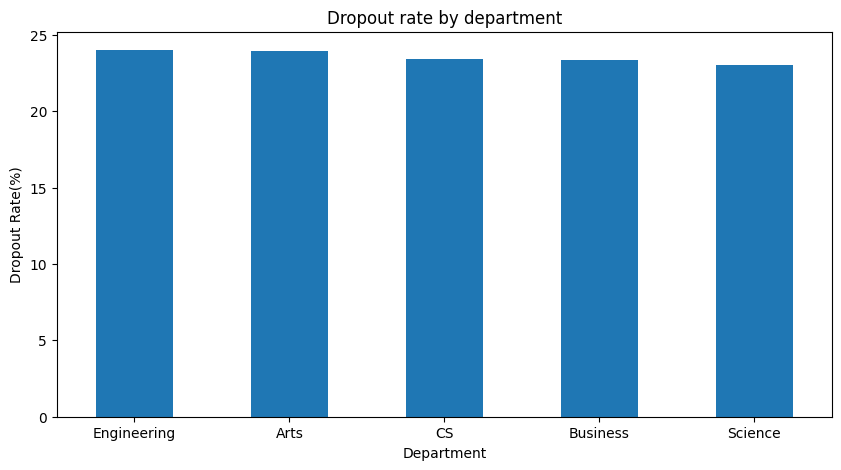

In [32]:
# Compare dropout rates across different departments
plt.figure(figsize=(10,5))
department_dropout.plot(kind='bar')
plt.title('Dropout rate by department')
plt.xlabel('Department')
plt.ylabel('Dropout Rate(%)')
plt.xticks(rotation=0)
plt.show()

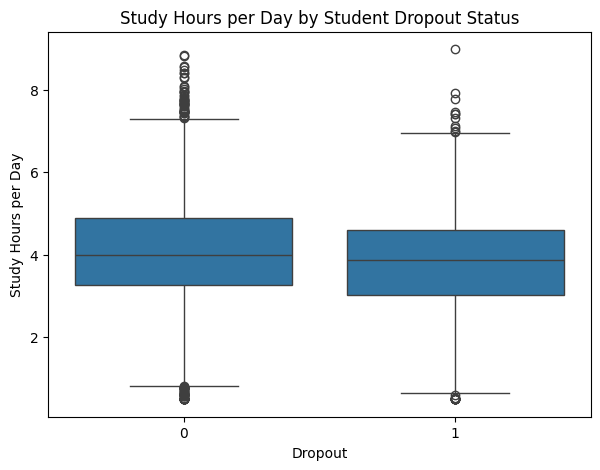

In [33]:
# Compare study hours between dropout and non-dropout students
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Dropout', y='Study_Hours_per_Day')
plt.title('Study Hours per Day by Student Dropout Status')
plt.xlabel('Dropout')
plt.ylabel('Study Hours per Day')
plt.show()

In [34]:
numeric_df= df.select_dtypes(include='number')

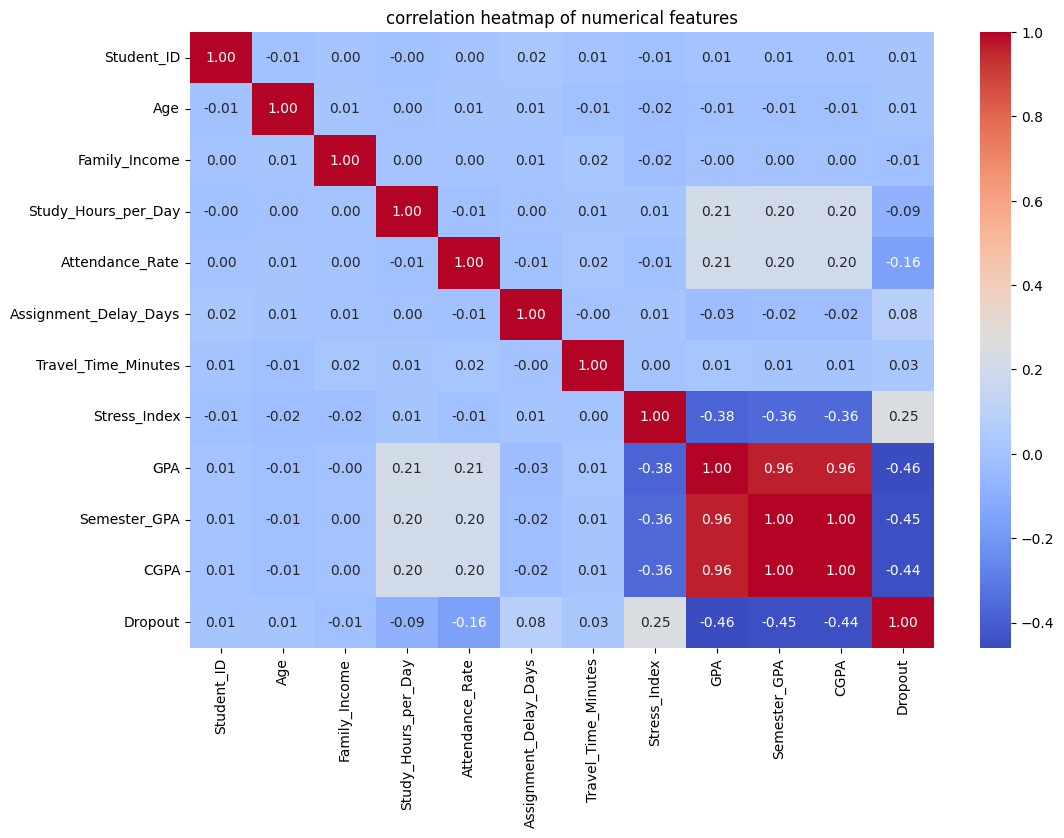

In [ ]:
#correlation heatmap of numerical features
plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('correlation heatmap of numerical features')
plt.show()

In [36]:
df=df.drop(columns=['Student_ID'])

In [37]:
df.select_dtypes(include='object').columns

Index(['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester',
       'Department', 'Parental_Education'],
      dtype='object')

In [38]:
df['Parental_Education'].value_counts()

Parental_Education
Bachelor       4460
High School    3072
Master         2003
PhD             465
Name: count, dtype: int64

Ordinal encoding

In [39]:
education_mapping={
    'High School':0,
    'Bachelor':1,
    'Master':2,
    'PhD':3,
}

df['Parental_Education']=df['Parental_Education'].map(education_mapping)

In [40]:
df=pd.get_dummies(
    df,
    columns=['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship','Semester', 'Department'],
    drop_first=True,
    dtype=int
)

In [41]:
df.head()

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,...,Internet_Access_Yes,Part_Time_Job_Yes,Scholarship_Yes,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science
0,22.1,25000.0,3.36,86.1,2,20.4,5.5,0.96,0.90,0.90,...,1,1,0,0,0,0,0,0,0,0
1,20.7,25000.0,4.30,68.0,2,44.0,6.8,1.28,1.20,1.19,...,1,0,0,0,1,0,0,0,1,0
2,22.4,40183.0,4.40,70.9,0,48.9,5.5,1.68,1.32,1.32,...,1,1,0,0,0,0,0,0,0,0
3,24.4,29740.5,4.00,82.2,2,38.6,5.5,1.78,1.77,1.77,...,1,0,0,0,0,0,0,1,0,0
4,20.5,25319.0,4.19,75.7,1,23.0,7.0,1.48,0.91,0.87,...,1,0,0,0,0,1,1,0,0,0


In [42]:
df.dtypes

Age                       float64
Family_Income             float64
Study_Hours_per_Day       float64
Attendance_Rate           float64
Assignment_Delay_Days       int64
Travel_Time_Minutes       float64
Stress_Index              float64
GPA                       float64
Semester_GPA              float64
CGPA                      float64
Parental_Education          int64
Dropout                     int64
Gender_Male                 int64
Internet_Access_Yes         int64
Part_Time_Job_Yes           int64
Scholarship_Yes             int64
Semester_Year 2             int64
Semester_Year 3             int64
Semester_Year 4             int64
Department_Business         int64
Department_CS               int64
Department_Engineering      int64
Department_Science          int64
dtype: object

In [ ]:
# Separate the features (X) from the target variable (y)
X= df.drop(columns=['Dropout'])
y=df['Dropout']

In [44]:
print("X shape:",X.shape)
print("y shape:", y.shape)

X shape: (10000, 22)
y shape: (10000,)


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train,y_test= train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [46]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:",  y_test.shape)

X_train: (8000, 22)
X_test: (2000, 22)
y_train: (8000,)
y_test: (2000,)


Feature Scaling

In [47]:
scaler= StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [48]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (8000, 22)
X_test_scaled shape: (2000, 22)


In [81]:
# Create the Logistic Regression model
model=LogisticRegression(max_iter=1000, class_weight='balanced')


In [80]:
#Train the model
model.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
#Prediction
y_pred=model.predict(X_test_scaled)

In [51]:
#Classification report
print("Accuracy:", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.746
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1529
           1       0.48      0.76      0.59       471

    accuracy                           0.75      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.81      0.75      0.76      2000



In [52]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1132  397]
 [ 111  360]]


In [82]:
#Create the Decision Tree Model
dt_model= DecisionTreeClassifier(random_state=42)


In [83]:
#Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [84]:
#Prediction
y_pred_dt= dt_model.predict(X_test)

In [85]:
print("Accuracy score: ", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy score:  0.737
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1529
           1       0.44      0.45      0.45       471

    accuracy                           0.74      2000
   macro avg       0.64      0.64      0.64      2000
weighted avg       0.74      0.74      0.74      2000



In [86]:
#Create  the Random forest model
rf_model = RandomForestClassifier(random_state=42)

In [87]:
#Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [90]:
#Prediction
y_pred_rf = rf_model.predict(X_test)

In [89]:
#Classification report
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.801
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1529
           1       0.64      0.36      0.46       471

    accuracy                           0.80      2000
   macro avg       0.73      0.65      0.67      2000
weighted avg       0.78      0.80      0.78      2000



In [ ]:
# Create the Logistic Regression model for cross-validation
lr_model= LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
# Evaluate the model using 5-fold cross-validation 
lr_cv_scores=cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='recall'
)

In [96]:
print("Cross-validation scores of lr_model:", lr_cv_scores)
print("Mean CV Recall:", lr_cv_scores.mean())

Cross-validation scores of lr_model: [0.72148541 0.74801061 0.74535809 0.80053191 0.74734043]
Mean CV Recall: 0.7525452903662735


In [ ]:
#  Hyperparameter values to test for Logistic Regression
param_grid_lr={
    'C':[0.01,0.1,1,10,100],
    'solver':['liblinear', 'lbfgs']
    

}

In [ ]:
# Hyperparameters using 5-fold cross-validation
grid_search_lr= GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='recall',
    n_jobs=1
)

In [63]:

grid_search_lr.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          max_iter=1000, random_state=42),
             n_jobs=1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='recall')

In [64]:
print("Best parameters: ", grid_search_lr.best_params_)

Best parameters:  {'C': 0.1, 'solver': 'liblinear'}


In [65]:
print("Best recall: ", grid_search_lr.best_score_)

Best recall:  0.7546644844517185


In [66]:
best_lr_model = grid_search_lr.best_estimator_

y_pred_best_lr = best_lr_model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred_best_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_lr))

Test Accuracy: 0.745

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1529
           1       0.47      0.77      0.59       471

    accuracy                           0.74      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.81      0.74      0.76      2000



final predications 

In [98]:
best_lr_model= grid_search_lr.best_estimator_

In [99]:
y_pred_final= best_lr_model.predict(X_test_scaled)

In [100]:
accuracy=accuracy_score(y_test, y_pred_final)
print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.745


In [101]:
cm=confusion_matrix(y_test, y_pred_final)
print("confusion_matrix:")
print(cm)
print(classification_report(y_test, y_pred_final))

confusion_matrix:
[[1129  400]
 [ 110  361]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1529
           1       0.47      0.77      0.59       471

    accuracy                           0.74      2000
   macro avg       0.69      0.75      0.70      2000
weighted avg       0.81      0.74      0.76      2000



In [77]:
with open('model.pkl', 'wb') as file:
    pickle.dump(best_lr_model,file)

In [78]:
with open('scaler.pkl','wb') as file:
    pickle.dump(scaler,file)

In [79]:
with open('feature_columns.pkl', 'wb') as file:
    pickle.dump(X.columns.tolist(),file)